# Wearables Glove Project - Experimental Results

Reproduz a pipeline do jogo sem o jogar:
1. **Calibracao** - curva piecewise linear identica ao `data_preprocessing.py`
2. **Normalizacao** - aplicar calibracao a dados brutos do raw data script
3. **Analise de tremores** - mesma FFT de `imu_tremor_analysis()` do jogo
4. **Sweep de frequencias** - testar deteccao sem hardware

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [39]:
GAME_CSV    = "recordings/Patient_levelA_20260618_133259.csv"
RAW_CSV     = None   # ex: "adc_data_20260618_100032.csv"
SAMPLE_RATE = 60.0
TREMOR_LOW  = 4.0
TREMOR_HIGH = 7.0

FINGER_RAW_COLS = {
    "Thumb":  "Channel_9",
    "Index":  "Channel_13",
    "Middle": "Channel_5",
    "Ring":   "Channel_6",
    "Pinky":  "Channel_10",
}
IMU_RAW_COLS = ["Channel_15", "Channel_16", "Channel_17"]
COLORS = plt.cm.tab10(range(5))

## 1. Calibracao

In [40]:
def _is_float(s):
    try: float(s); return True
    except: return False

def load_calibration(path):
    calib, names = {}, []
    with open(path) as f:
        for line in f:
            p = [x.strip() for x in line.rstrip("\n").split(",")]
            if p[0] == "#":
                names = [x for x in p[1:] if x and not x.startswith("ch")]
            elif p[0] in ("calib_closed","calib_half","calib_open","calib_span"):
                key = p[0].replace("calib_","")
                vals = [float(x) for x in p[1:] if x and _is_float(x)]
                calib[key] = np.array(vals[:len(names)] if names else vals)
            elif p[0] == "time_s":
                break
    return calib, names

calib, finger_names = load_calibration(GAME_CSV)
if not finger_names: finger_names = list(FINGER_RAW_COLS.keys())
n_fingers = len(finger_names)
spans     = calib["span"]

print(f"Dedos: {finger_names}\n")
print(f'{"Dedo":<10} {"Closed":>12} {"Half":>12} {"Open":>12} {"Span":>12}')
print("-"*52)
for i, nm in enumerate(finger_names):
    print(f"{nm:<10} {calib[\"closed\"][i]:>12.1f} {calib[\"half\"][i]:>12.1f}",
          f"{calib[\"open\"][i]:>12.1f} {calib[\"span\"][i]:>12.1f}")

SyntaxError: unexpected character after line continuation character (940569293.py, line 29)

### 1.1 Funcoes de normalizacao (identicas ao jogo)

In [41]:
# Copia exacta de _piecewise_interp de data_preprocessing.py
def piecewise_interp(v, v_closed, v_half, v_open):
    span_lo = v_half - v_closed
    span_hi = v_open  - v_half
    if (v_closed <= v <= v_half) or (v_half <= v <= v_closed):
        return -1.0 if span_lo == 0 else -1.0 + (v - v_closed) / span_lo
    else:
        return  0.0 if span_hi == 0 else  0.0 + (v - v_half)   / span_hi

def normalize_finger(raw_vals, v_closed, v_half, v_open):
    v_lo = min(v_closed, v_open); v_hi = max(v_closed, v_open)
    clamped = np.clip(np.asarray(raw_vals, float), v_lo, v_hi)
    return np.clip([piecewise_interp(v, v_closed, v_half, v_open) for v in clamped], -1.0, 1.0)

### 1.2 Plot da curva de calibracao + media dos 5 dedos

In [43]:
fig, axes = plt.subplots(1, n_fingers + 1, figsize=(3.5*(n_fingers+1), 4),
                         sharey=True, constrained_layout=True)
fig.suptitle("Curvas de calibracao - piecewise linear (identico ao jogo)", fontsize=13)

curves_norm = []
x_norm = np.linspace(0, 1, 300)  # 0=closed, 0.5=half, 1=open

for i, (ax, name) in enumerate(zip(axes[:-1], finger_names)):
    v_cl = calib["closed"][i]; v_h = calib["half"][i]; v_op = calib["open"][i]
    v_lo, v_hi = min(v_cl, v_op), max(v_cl, v_op)
    v_rng = np.linspace(v_lo, v_hi, 300)
    ap_rng = normalize_finger(v_rng, v_cl, v_h, v_op)

    ax.plot(v_rng, ap_rng, color=COLORS[i], lw=2.5)
    ax.scatter([v_cl, v_h, v_op], [-1, 0, 1], color=COLORS[i], s=80, zorder=5, edgecolors="k", lw=0.8)
    for vx, vy, lbl in zip([v_cl,v_h,v_op],[-1,0,1],["Closed(-1)","Half(0)","Open(+1)"]):
        ax.annotate(lbl, (vx, vy), xytext=(5,0), textcoords="offset points", fontsize=7, color="gray")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_title(name, color=COLORS[i]); ax.set_xlabel("Raw ADC")
    ax.set_ylim(-1.3, 1.3); ax.grid(True, alpha=0.25)

    # curva em eixo normalizado para o painel da media
    v_range_i = v_cl + x_norm * (v_op - v_cl)
    curves_norm.append(normalize_finger(v_range_i, v_cl, v_h, v_op))

axes[0].set_ylabel("Aperture")

ax_m = axes[-1]
for i, nm in enumerate(finger_names):
    ax_m.plot(x_norm, curves_norm[i], color=COLORS[i], lw=1, alpha=0.45, label=nm)
mean_curve = np.average(curves_norm, axis=0, weights=spans)
ax_m.plot(x_norm, mean_curve, color="black", lw=2.5, label="Media (span)")
ax_m.axhline(0, color="gray", lw=0.5, ls="--")
ax_m.set_xlabel("Posicao normalizada\n(0=closed  0.5=half  1=open)")
ax_m.set_title("Media ponderada (span)", fontweight="bold")
ax_m.legend(fontsize=8); ax_m.grid(True, alpha=0.25)

plt.savefig("calibration_curves.png", bbox_inches="tight")
plt.show()

print("\nSpans (maior = sensor mais fiavel):")
for nm, s in zip(finger_names, spans):
    bar = chr(9608) * int(s / max(spans) * 30)
    print(f"  {nm:<8} {s:>10.0f}  {bar}")

NameError: name 'n_fingers' is not defined

## 2. Normalizar dados brutos (do raw data script)

In [44]:
def load_game_data(path):
    with open(path) as f: lines = f.readlines()
    start = next(i for i, l in enumerate(lines) if l.startswith("time_s"))
    return pd.read_csv(path, skiprows=start)

if RAW_CSV is None:
    print("RAW_CSV=None -> a usar dados do CSV do jogo (ja normalizados)")
    df = load_game_data(GAME_CSV)
    print(f"{len(df)} amostras, colunas: {list(df.columns)}")
    t = df["time_s"].values
    apertures = {nm: df[nm].values for nm in finger_names if nm in df.columns}
else:
    df_raw = pd.read_csv(RAW_CSV)
    print(f"CSV bruto: {len(df_raw)} linhas, colunas: {list(df_raw.columns)}")
    t = np.arange(len(df_raw)) / SAMPLE_RATE
    apertures = {}
    for i, nm in enumerate(finger_names):
        col = FINGER_RAW_COLS.get(nm)
        if col not in df_raw.columns: print(f"  AVISO: {col} nao encontrada"); continue
        apertures[nm] = normalize_finger(df_raw[col].values,
            calib["closed"][i], calib["half"][i], calib["open"][i])
        print(f"  {nm}: [{apertures[nm].min():.3f}, {apertures[nm].max():.3f}]")

valid_names = [nm for nm in finger_names if nm in apertures]
arr_ap  = np.array([apertures[nm] for nm in valid_names])
w_ap    = np.array([spans[finger_names.index(nm)] for nm in valid_names])
mean_ap = np.average(arr_ap, axis=0, weights=w_ap)
print(f"\nApertura media: [{mean_ap.min():.3f}, {mean_ap.max():.3f}]")

RAW_CSV=None -> a usar dados do CSV do jogo (ja normalizados)
1205 amostras, colunas: ['time_s', 'Thumb', 'Index', 'Middle', 'Ring', 'Pinky', 'ch15', 'ch16', 'ch17']

Apertura media: [-0.974, 0.977]


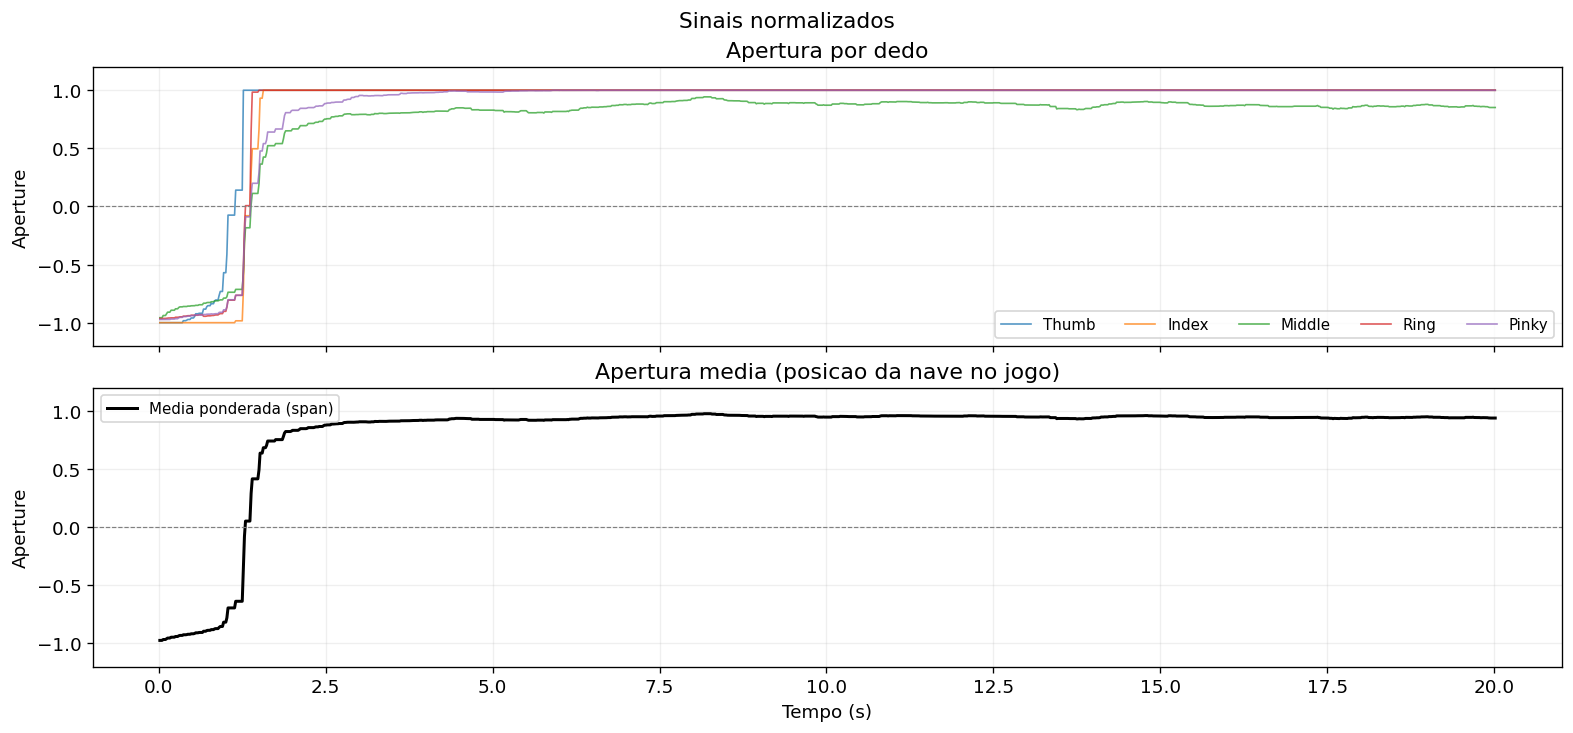

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
fig.suptitle("Sinais normalizados", fontsize=13)

for i, nm in enumerate(valid_names):
    ax1.plot(t, apertures[nm], color=COLORS[i%5], lw=1, alpha=0.75, label=nm)
ax1.axhline(0, color="gray", ls="--", lw=0.7)
ax1.set_ylabel("Aperture"); ax1.set_ylim(-1.2, 1.2)
ax1.legend(ncol=5, fontsize=9); ax1.grid(True, alpha=0.2)
ax1.set_title("Apertura por dedo")

ax2.plot(t, mean_ap, color="black", lw=1.8, label="Media ponderada (span)")
ax2.axhline(0, color="gray", ls="--", lw=0.7)
ax2.set_xlabel("Tempo (s)"); ax2.set_ylabel("Aperture")
ax2.set_ylim(-1.2, 1.2); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)
ax2.set_title("Apertura media (posicao da nave no jogo)")

plt.savefig("normalized_signal.png", bbox_inches="tight")
plt.show()

## 3. Analise de tremores IMU (identico ao jogo)

In [48]:
# Copia exacta de imu_tremor_analysis() de game.py
def imu_tremor_analysis(imu_rows, sr=60.0, low=4.0, high=7.0):
    arr = np.array(imu_rows, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 3 or arr.shape[0] < 32:
        return dict(dominant_hz=0.0, band_power=0.0, relative_power_pct=0.0, pct_time_tremor=0.0)
    arr -= arr.mean(axis=0)
    freqs = np.fft.rfftfreq(arr.shape[0], d=1.0/sr)
    power = np.zeros(len(freqs))
    for ch in range(arr.shape[1]): power += np.abs(np.fft.rfft(arr[:,ch]))**2
    mb = (freqs >= low) & (freqs <= high)
    dom  = float(freqs[mb][np.argmax(power[mb])]) if mb.any() and power[mb].max()>0 else 0.0
    bp   = float(power[mb].sum()) if mb.any() else 0.0
    rp   = 100.0*bp/float(power.sum()) if power.sum()>0 else 0.0
    win  = max(16, int(sr)); hop = max(1, win//2)
    wf   = np.fft.rfftfreq(win, d=1.0/sr); wm = (wf>=low)&(wf<=high)
    tw = tot = 0
    for s in range(0, arr.shape[0]-win+1, hop):
        c  = arr[s:s+win]
        wp = np.zeros(len(wf))
        for ch in range(c.shape[1]): wp += np.abs(np.fft.rfft(c[:,ch]-c[:,ch].mean()))**2
        wt = wp.sum(); wb = wp[wm].sum() if wm.any() else 0.0
        if wt > 0 and (wb/wt) > 0.20: tw += 1
        tot += 1
    return dict(dominant_hz=dom, band_power=bp, relative_power_pct=rp,
                pct_time_tremor=100.0*tw/max(1,tot))

def print_tremor(res, label=""):
    print(f"\n--- Tremor {label} ---")
    print(f"  Frequencia dominante (4-7 Hz) : {res['dominant_hz']:.2f} Hz")
    print(f"  Band power total (4-7 Hz)     : {res['band_power']:.1f}")
    print(f"  Relative tremor power         : {res['relative_power_pct']:.1f} %")
    print(f"  % tempo com tremor activo     : {res['pct_time_tremor']:.1f} %")

In [50]:
if RAW_CSV is None:
    df = load_game_data(GAME_CSV)
    imu_cols = [c for c in ["ch15","ch16","ch17"] if c in df.columns]
    if imu_cols:
        imu_data = df[imu_cols].values
        sr_used  = 1.0 / float(np.median(np.diff(df["time_s"].values)))
        print(f"IMU: {imu_data.shape[0]} amostras @ {sr_used:.1f} Hz")
    else:
        print("Sem colunas IMU no CSV — usa a seccao 4 para teste sintetico"); imu_data=None; sr_used=SAMPLE_RATE
else:
    df_raw = pd.read_csv(RAW_CSV)
    imu_cols = [c for c in IMU_RAW_COLS if c in df_raw.columns]
    imu_data = df_raw[imu_cols].values if imu_cols else None; sr_used = SAMPLE_RATE

if imu_data is not None and imu_data.shape[1] >= 3:
    res = imu_tremor_analysis(imu_data, sr=sr_used, low=TREMOR_LOW, high=TREMOR_HIGH)
    print_tremor(res, "dados reais")

    arr = imu_data.astype(float); arr -= arr.mean(axis=0)
    ff  = np.fft.rfftfreq(len(arr), d=1.0/sr_used)
    pw  = np.zeros(len(ff))
    for ch in range(arr.shape[1]): pw += np.abs(np.fft.rfft(arr[:,ch]))**2

    fig, ax = plt.subplots(figsize=(11,4), constrained_layout=True)
    ax.semilogy(ff, pw, color="steelblue", lw=1.2, label="Power spectrum (3 eixos)")
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.15, color="red", label=f"{TREMOR_LOW}-{TREMOR_HIGH} Hz")
    if res["dominant_hz"]>0: ax.axvline(res["dominant_hz"], color="red", ls="--", lw=1.5,
                                         label=f"Dom. {res[\"dominant_hz\"]:.2f} Hz")
    ax.set_xlabel("Frequencia (Hz)"); ax.set_ylabel("Power (log)")
    ax.set_title("Espectro IMU - ch15+ch16+ch17 (apos remocao de DC)")
    ax.set_xlim(0, min(30, ff[-1])); ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
    plt.savefig("tremor_spectrum_real.png", bbox_inches="tight"); plt.show()

SyntaxError: unexpected character after line continuation character (2488386075.py, line 28)

## 4. Testar diferentes frequencias de tremor (sem hardware)

In [ ]:
def simulate_imu(freq_hz, duration_s=20.0, amplitude=200, sr=60.0, noise_std=15, dc_offset=500):
    """Sinal IMU sintetico com tremor + DC offset (removido antes da FFT)."""
    N = int(duration_s * sr); t = np.linspace(0, duration_s, N)
    c1 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t)         + np.random.normal(0,noise_std,N)
    c2 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t+np.pi/4) + np.random.normal(0,noise_std,N)
    c3 = dc_offset + amplitude*np.sin(2*np.pi*freq_hz*t+np.pi/2) + np.random.normal(0,noise_std,N)
    return np.column_stack([c1, c2, c3])

test_freqs = [1.0, 2.0, 3.0, 4.0, 5.0, 5.5, 6.0, 7.0, 8.0, 10.0, 15.0]
results = []
for freq in test_freqs:
    r = imu_tremor_analysis(simulate_imu(freq, sr=SAMPLE_RATE), sr=SAMPLE_RATE, low=TREMOR_LOW, high=TREMOR_HIGH)
    r["input_freq"] = freq; results.append(r)

df_res = pd.DataFrame(results)[["input_freq","dominant_hz","relative_power_pct","pct_time_tremor","band_power"]]
df_res.columns = ["Input (Hz)","Dominant Hz","Rel. power (%)","% time tremor","Band power"]
print(df_res.to_string(index=False, float_format="{:.2f}".format))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fig.suptitle("Resposta do detector vs frequencia de entrada", fontsize=13)
fi = [r["input_freq"] for r in results]
for ax in axes:
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.2, color="#ffcccc", label="Tremor band")
    ax.set_xlabel("Frequencia de entrada (Hz)"); ax.grid(True, alpha=0.2)

axes[0].plot(fi,[r["relative_power_pct"] for r in results],"o-",color="steelblue",lw=2)
axes[0].set_ylabel("Relative tremor power (%)"); axes[0].set_title("Potencia relativa")
axes[0].legend(fontsize=9)
axes[1].plot(fi,[r["pct_time_tremor"] for r in results],"s-",color="darkorange",lw=2)
axes[1].set_ylabel("% tempo com tremor"); axes[1].set_title("% tempo com tremor activo")
axes[2].plot(fi, fi, "--", color="gray", lw=1, label="Ideal")
axes[2].plot(fi,[r["dominant_hz"] for r in results],"^-",color="green",lw=2,label="Detectado")
axes[2].set_ylabel("Frequencia detectada (Hz)"); axes[2].set_title("Frequencia dominante")
axes[2].legend(fontsize=9)
plt.savefig("tremor_freq_sweep.png", bbox_inches="tight"); plt.show()

In [ ]:
n_cols = 4; n_rows = int(np.ceil(len(test_freqs)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 3*n_rows), constrained_layout=True)
fig.suptitle("Espectros por frequencia  (vermelho=banda 4-7Hz  verde=freq input)", fontsize=12)
flat = axes.flatten()
for ax, freq, res in zip(flat, test_freqs, results):
    sim = simulate_imu(freq, sr=SAMPLE_RATE)
    arr = sim - sim.mean(axis=0)
    ff  = np.fft.rfftfreq(len(arr), d=1.0/SAMPLE_RATE)
    pw  = np.zeros(len(ff))
    for ch in range(3): pw += np.abs(np.fft.rfft(arr[:,ch]))**2
    ax.semilogy(ff, pw, color="steelblue", lw=1)
    ax.axvspan(TREMOR_LOW, TREMOR_HIGH, alpha=0.2, color="red")
    ax.axvline(freq, color="green", ls="--", lw=1.2)
    ax.set_title(f"{freq} Hz -> det: {res[\"dominant_hz\"]:.1f} Hz", fontsize=9)
    ax.set_xlim(0, 20); ax.set_xlabel("Hz", fontsize=8); ax.tick_params(labelsize=7)
for ax in flat[len(test_freqs):]: ax.set_visible(False)
plt.savefig("tremor_spectra_grid.png", bbox_inches="tight"); plt.show()

## TEST 1 — Abertura/fecho a diferentes velocidades (low / med / high)

Calibracao **por dados**: cada canal usa o seu proprio min/max dentro de cada teste.
Nao depende do CSV do jogo — adequado quando as sessoes foram feitas em momentos diferentes.

- `aperture = +1` → mao aberta (ADC minimo do canal)
- `aperture = -1` → mao fechada (ADC maximo do canal)

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST1_DIR = "RECORDINGS FOR TEST/"
TEST1_FILES = {
    "low" : TEST1_DIR + "test1_low freq.csv",
    "med" : TEST1_DIR + "test1_med freq.csv",
    "high": TEST1_DIR + "test1_high freq.csv",
}
TEST1_COLORS = {"low": "steelblue", "med": "darkorange", "high": "crimson"}

CHANNELS = {
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_8" : "Ch8",
    "Channel_9" : "Thumb",
    "Channel_10": "Pinky",
}
CH_COLS  = list(CHANNELS.keys())
CH_NAMES = list(CHANNELS.values())
COLORS5  = plt.cm.tab10(range(5))
MA_WINDOW  = 30
T_START    = 4.0   # segundo de inicio da janela de analise
T_END      = 23.0  # segundo de fim da janela de analise

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

tests = {}
for label, path in TEST1_FILES.items():
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    t  = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().values

    # 1. Moving average nos dados brutos
    smoothed = {col: moving_average(df[col].values.astype(float), MA_WINDOW)
                for col in CH_COLS if col in df.columns}

    # 2. Mascara da janela de analise (para calibracao e plots)
    mask = (t >= T_START) & (t <= T_END)
    print(f"{label}: {mask.sum()} amostras na janela [{T_START}s, {T_END}s]")

    # 3. Calibracao: min/max calculados SO dentro da janela
    calib_test = {}
    aps = {}
    for col, arr in smoothed.items():
        arr_w = arr[mask]
        vmin, vmax = arr_w.min(), arr_w.max()
        calib_test[col] = (vmin, vmax)
        # Normalizar todo o sinal com os limites da janela (pode sair de [-1,1] fora)
        aps[col] = normalize_linear(arr, vmin, vmax)

    # 4. Media ponderada pelo span (dentro da janela)
    avail   = [c for c in CH_COLS if c in aps]
    arr_all = np.array([aps[c] for c in avail])
    spans   = np.array([calib_test[c][1] - calib_test[c][0] for c in avail])
    mean_ap = np.average(arr_all, axis=0, weights=spans)

    tests[label] = dict(df=df, t=t, mask=mask, smoothed=smoothed,
                        aps=aps, mean_ap=mean_ap, calib=calib_test)
    ap_w = mean_ap[mask]
    print(f"  apertura na janela [{ap_w.min():.2f}, {ap_w.max():.2f}]\n")

low: 1902 amostras na janela [4.0s, 23.0s]
  apertura na janela [-0.99, 0.94]

med: 1884 amostras na janela [4.0s, 23.0s]
  apertura na janela [-0.92, 0.99]

high: 1896 amostras na janela [4.0s, 23.0s]
  apertura na janela [-0.91, 0.96]



### Retas de calibracao — 5 canais × 3 testes (15 graficos)

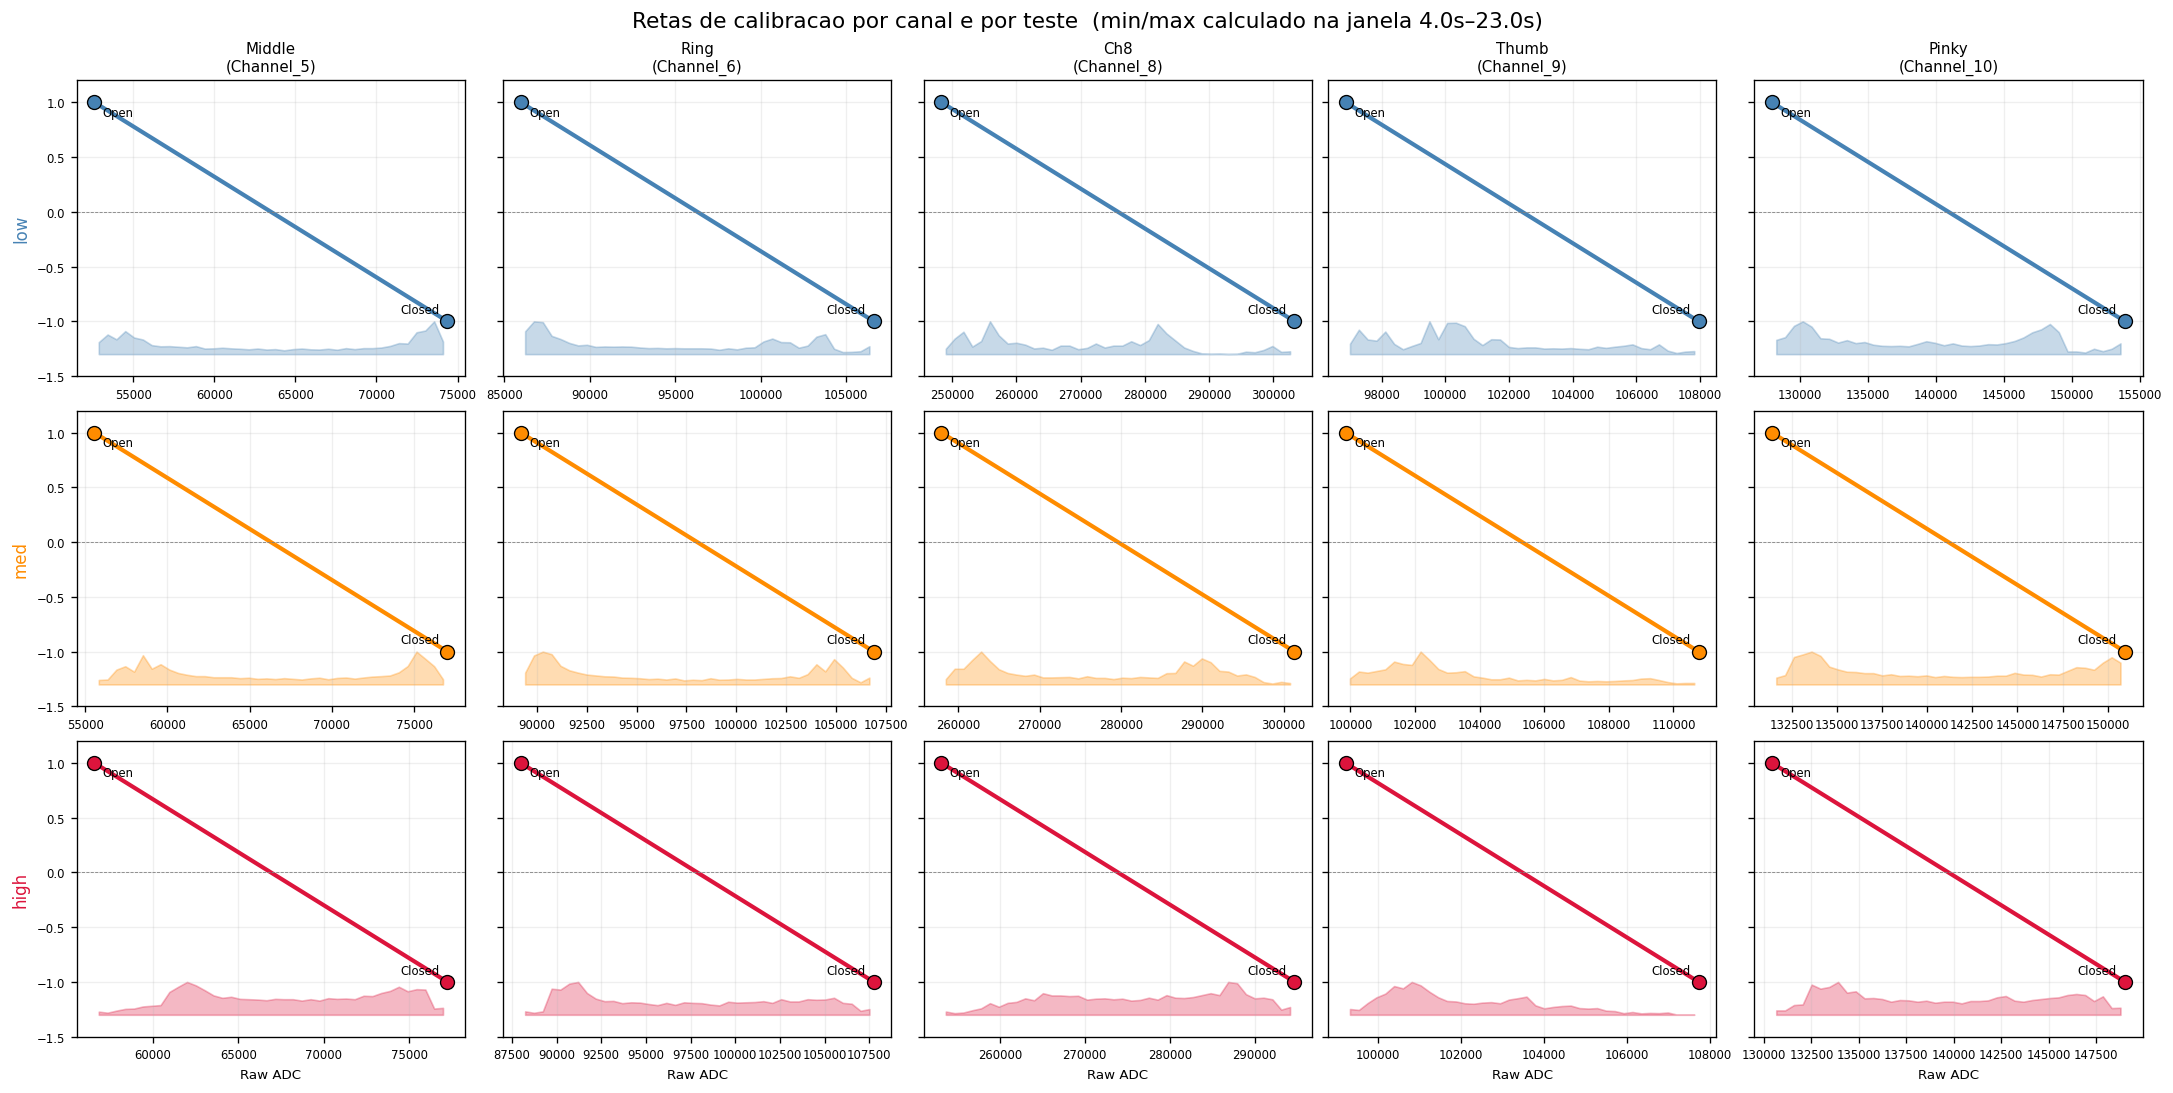

In [55]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"Retas de calibracao por canal e por teste  "
    f"(min/max calculado na janela {T_START}s–{T_END}s)",
    fontsize=13)

for row, (label, td) in enumerate(tests.items()):
    for col_i, (col, nm) in enumerate(CHANNELS.items()):
        ax = axes[row][col_i]
        if col not in td["calib"]:
            ax.set_visible(False); continue
        vmin, vmax = td["calib"][col]

        # Reta de calibracao linear
        v_rng  = np.linspace(vmin, vmax, 200)
        ap_rng = normalize_linear(v_rng, vmin, vmax)
        ax.plot(v_rng, ap_rng, color=TEST1_COLORS[label], lw=2.5)

        # Pontos de referencia
        ax.scatter([vmax, vmin], [-1, 1], color=TEST1_COLORS[label],
                   s=70, zorder=5, edgecolors="black", lw=0.8)
        ax.annotate("Closed", (vmax, -1), xytext=(-5, 5),
                    textcoords="offset points", fontsize=7, ha="right")
        ax.annotate("Open",   (vmin,  1), xytext=(5, -8),
                    textcoords="offset points", fontsize=7)

        # Histograma so dentro da janela de analise
        raw_w = td["smoothed"][col][td["mask"]]
        hist, edges = np.histogram(raw_w, bins=40, range=(vmin, vmax))
        hist_norm = hist / hist.max() * 0.3
        ax.fill_between((edges[:-1]+edges[1:])/2, -1.3, -1.3+hist_norm,
                        alpha=0.3, color=TEST1_COLORS[label])

        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.set_ylim(-1.5, 1.2)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

        if row == 0: ax.set_title(f"{nm}\n({col})", fontsize=9)
        if col_i == 0: ax.set_ylabel(f"{label}", fontsize=10, color=TEST1_COLORS[label])
        if row == 2: ax.set_xlabel("Raw ADC", fontsize=8)

plt.savefig("test1_calibration_curves.png", bbox_inches="tight")
plt.show()

### Apertura media ao longo do tempo — um plot por teste

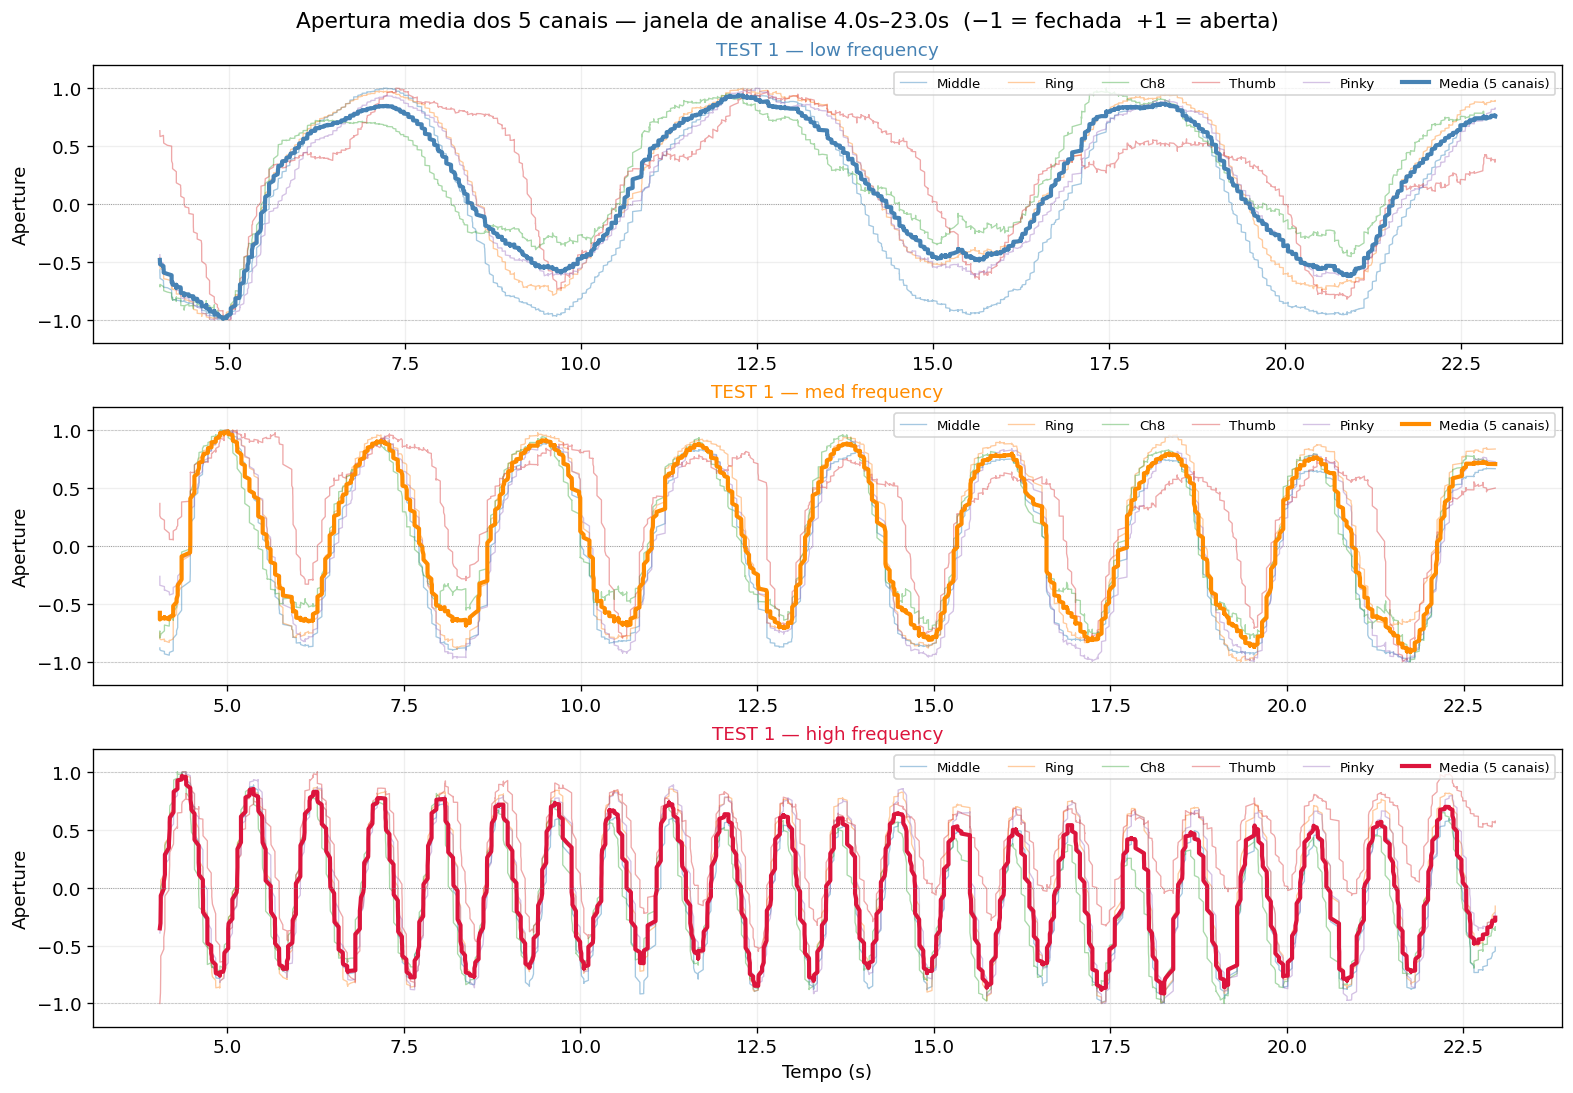

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"Apertura media dos 5 canais — janela de analise {T_START}s–{T_END}s"
    "  (−1 = fechada  +1 = aberta)", fontsize=13)

for ax, (label, td) in zip(axes, tests.items()):
    t_w  = td["t"][td["mask"]]
    # Canais individuais
    for i, (col, nm) in enumerate(CHANNELS.items()):
        if col not in td["aps"]: continue
        ax.plot(t_w, td["aps"][col][td["mask"]],
                color=COLORS5[i], lw=0.8, alpha=0.4, label=nm)
    # Media em destaque
    ax.plot(t_w, td["mean_ap"][td["mask"]],
            color=TEST1_COLORS[label], lw=2.5, label="Media (5 canais)")
    ax.axhline( 0, color="gray", lw=0.5, ls=":")
    ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.set_ylabel("Aperture")
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f"TEST 1 — {label} frequency", color=TEST1_COLORS[label], fontsize=11)
    ax.legend(ncol=6, fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Tempo (s)")
plt.savefig("test1_signal.png", bbox_inches="tight")
plt.show()

## TEST 2 — Fecho sequencial de cada dedo (test2_v1)

Protocolo: fechar um dedo de cada vez durante 5s, abrir a mao 2s, passar ao seguinte.
Cada canal deve mostrar exactamente **uma descida** (fecho) durante o seu turno.

In [57]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

TEST2_FILE = "RECORDINGS FOR TEST/test2_v1.csv"
MA_WINDOW2 = 30
T_START2   = 2.0   # ajustar se necessario
T_END2     = 40.0  # ajustar se necessario

CHANNELS2 = {
    "Channel_9" : "Thumb",
    "Channel_8" : "Index",
    "Channel_5" : "Middle",
    "Channel_6" : "Ring",
    "Channel_10": "Pinky",
}
CH_COLS2  = list(CHANNELS2.keys())
CH_NAMES2 = list(CHANNELS2.values())
COLORS5   = plt.cm.tab10(range(5))

def moving_average(arr, w):
    return np.convolve(arr, np.ones(w)/w, mode="same")

def normalize_linear(values, vmin, vmax):
    span = vmax - vmin
    if span == 0: return np.zeros_like(values, dtype=float)
    return np.clip((vmax - np.asarray(values, float)) / span * 2 - 1, -1.0, 1.0)

df2 = pd.read_csv(TEST2_FILE, parse_dates=["Timestamp"])
t2  = (df2["Timestamp"] - df2["Timestamp"].iloc[0]).dt.total_seconds().values

# 1. Moving average nos dados brutos
smoothed2 = {col: moving_average(df2[col].values.astype(float), MA_WINDOW2)
             for col in CH_COLS2 if col in df2.columns}

# 2. Janela de analise
mask2 = (t2 >= T_START2) & (t2 <= T_END2)
print(f"{mask2.sum()} amostras na janela [{T_START2}s, {T_END2}s]")

# 3. Calibracao: min/max dentro da janela
calib2, aps2 = {}, {}
for col, arr in smoothed2.items():
    arr_w = arr[mask2]
    vmin, vmax = arr_w.min(), arr_w.max()
    calib2[col] = (vmin, vmax)
    aps2[col]   = normalize_linear(arr, vmin, vmax)
    print(f"  {CHANNELS2[col]} ({col}): ADC [{vmin:.0f}, {vmax:.0f}]  "
          f"apertura [{aps2[col][mask2].min():.2f}, {aps2[col][mask2].max():.2f}]")

3798 amostras na janela [2.0s, 40.0s]
  Middle (Channel_5): ADC [48912, 66526]  apertura [-1.00, 1.00]
  Ring (Channel_6): ADC [80656, 95473]  apertura [-1.00, 1.00]
  Ch8 (Channel_8): ADC [225024, 278912]  apertura [-1.00, 1.00]
  Thumb (Channel_9): ADC [93507, 123818]  apertura [-1.00, 1.00]
  Pinky (Channel_10): ADC [120753, 138418]  apertura [-1.00, 1.00]


### Curvas de calibracao — 5 canais

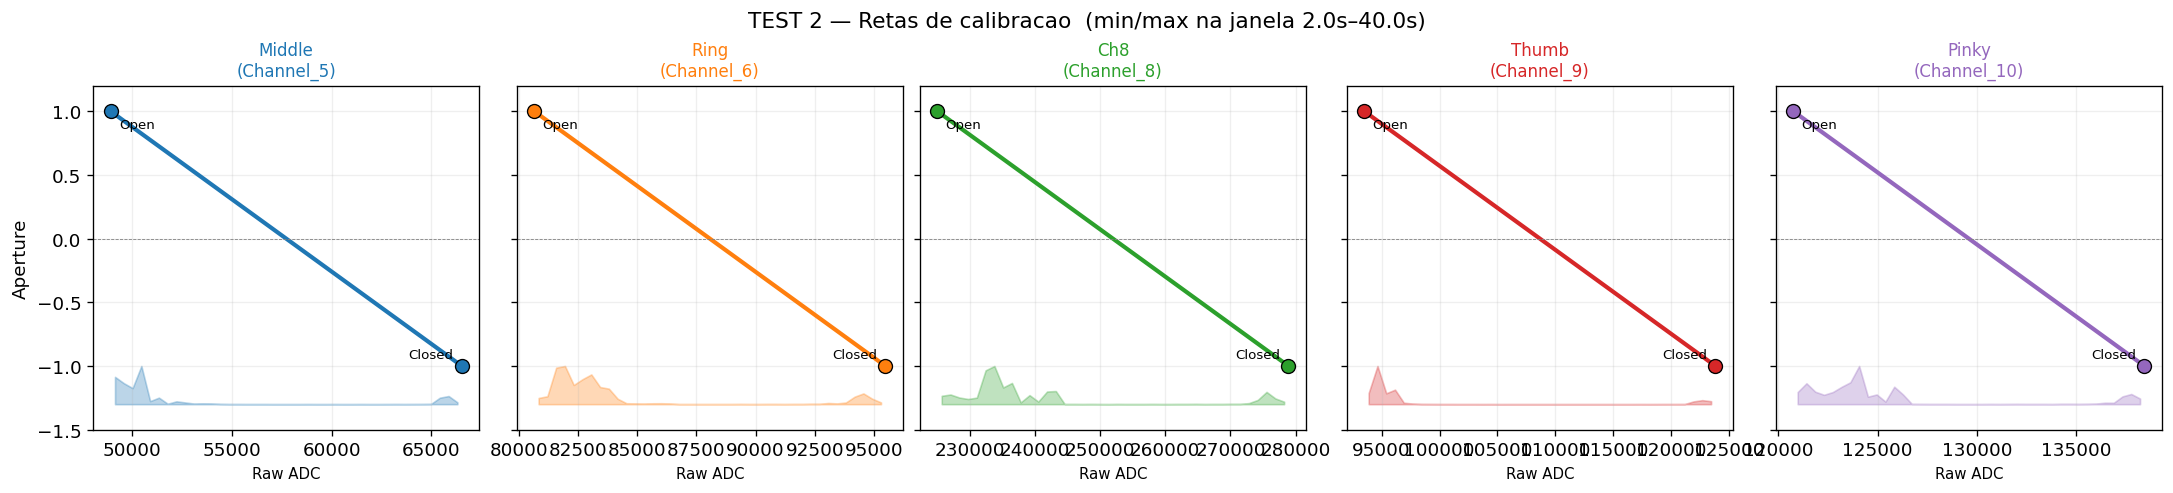

In [58]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4),
                         sharey=True, constrained_layout=True)
fig.suptitle(
    f"TEST 2 — Retas de calibracao  (min/max na janela {T_START2}s–{T_END2}s)",
    fontsize=13)

for ax, (col, nm), color in zip(axes, CHANNELS2.items(), COLORS5):
    if col not in calib2: ax.set_visible(False); continue
    vmin, vmax = calib2[col]

    v_rng  = np.linspace(vmin, vmax, 200)
    ap_rng = normalize_linear(v_rng, vmin, vmax)
    ax.plot(v_rng, ap_rng, color=color, lw=2.5)

    ax.scatter([vmax, vmin], [-1, 1], color=color,
               s=70, zorder=5, edgecolors="black", lw=0.8)
    ax.annotate("Closed", (vmax, -1), xytext=(-5, 5),
                textcoords="offset points", fontsize=8, ha="right")
    ax.annotate("Open",   (vmin,  1), xytext=(5, -10),
                textcoords="offset points", fontsize=8)

    # Histograma dos dados da janela
    raw_w = smoothed2[col][mask2]
    hist, edges = np.histogram(raw_w, bins=40, range=(vmin, vmax))
    hist_norm = hist / hist.max() * 0.3
    ax.fill_between((edges[:-1]+edges[1:])/2, -1.3, -1.3+hist_norm,
                    alpha=0.3, color=color)

    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_title(f"{nm}\n({col})", color=color, fontsize=10)
    ax.set_xlabel("Raw ADC", fontsize=9)
    ax.set_ylim(-1.5, 1.2)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Aperture")
plt.savefig("test2_calibration_curves.png", bbox_inches="tight")
plt.show()

### Apertura por dedo — sequencia de fecho

Cada mini-plot mostra um canal. Deves ver **uma descida** por canal no momento
em que esse dedo foi fechado.

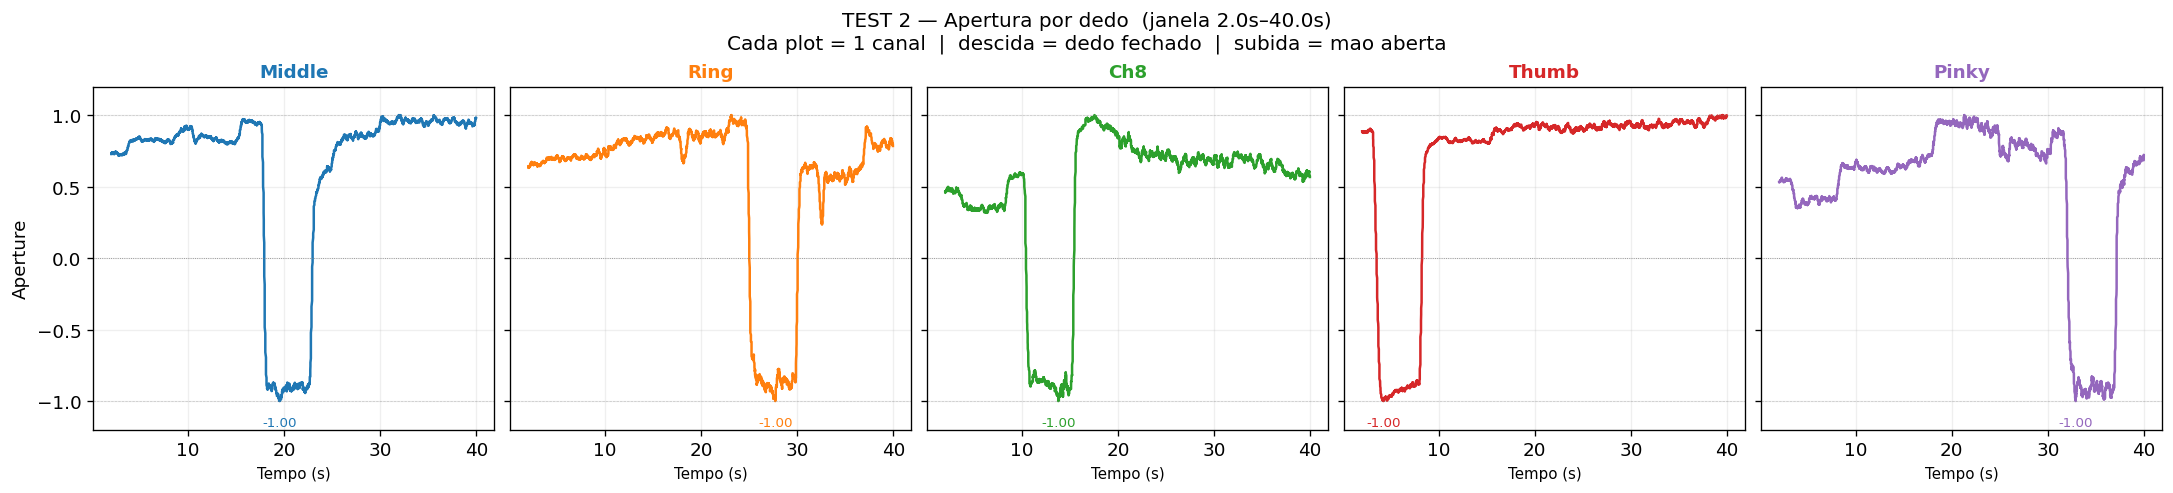

In [59]:
# Ordem anatomica: Thumb -> Index -> Middle -> Ring -> Pinky
ANAT_ORDER = ["Channel_9", "Channel_8", "Channel_5", "Channel_6", "Channel_10"]

fig, axes = plt.subplots(5, 1, figsize=(13, 12),
                         sharex=True, sharey=True, constrained_layout=True)
fig.suptitle(
    f"TEST 2 — Apertura por dedo  (janela {T_START2}s–{T_END2}s)\n"
    "descida = dedo fechado  |  subida = mao aberta",
    fontsize=12)

t2_w = t2[mask2]

for ax, col, color in zip(axes, ANAT_ORDER, COLORS5):
    if col not in aps2: ax.set_visible(False); continue
    nm   = CHANNELS2[col]
    ap_w = aps2[col][mask2]

    ax.plot(t2_w, ap_w, color=color, lw=1.5)
    ax.fill_between(t2_w, ap_w, 0,
                    where=(ap_w < 0), alpha=0.15, color=color,
                    label="fechado")
    ax.axhline( 0, color="gray", lw=0.6, ls=":")
    ax.axhline( 1, color="gray", lw=0.4, ls="--", alpha=0.4)
    ax.axhline(-1, color="gray", lw=0.4, ls="--", alpha=0.4)

    # Anotacao do minimo
    idx_min = np.argmin(ap_w)
    ax.annotate(f"min={ap_w[idx_min]:.2f}",
                xy=(t2_w[idx_min], ap_w[idx_min]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=8, color=color)

    ax.set_ylabel(nm, color=color, fontsize=11, fontweight="bold", rotation=0,
                  labelpad=45, va="center")
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Tempo (s)", fontsize=10)
plt.savefig("test2_signal.png", bbox_inches="tight")
plt.show()